# 📊 Marketing Funnel & Conversion Performance Analysis
**Future Interns — Data Science & Analytics Internship**  
**Task 3 | FUTURE_DS_03**

---
### Objective
Analyze the Olist marketing funnel data to identify conversion drop-offs, channel performance, and lead behavior trends to provide actionable business recommendations.

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## 2. Load & Merge Datasets

In [6]:
import pandas as pd

mql = pd.read_csv('../dataset/olist_marketing_qualified_leads_dataset.csv')
deals = pd.read_csv('../dataset/olist_closed_deals_dataset.csv')

print('MQL Dataset:', mql.shape)
print('Closed Deals Dataset:', deals.shape)
mql.head()


MQL Dataset: (8000, 4)
Closed Deals Dataset: (842, 14)


,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [7]:
deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [8]:
# Merge on mql_id (left join — keep all leads)
df = mql.merge(deals, on='mql_id', how='left')
df['converted'] = df['won_date'].notna().astype(int)

# Parse dates
df['first_contact_date'] = pd.to_datetime(df['first_contact_date'])
df['won_date'] = pd.to_datetime(df['won_date'])
df['contact_month'] = df['first_contact_date'].dt.to_period('M').astype(str)
df['contact_quarter'] = df['first_contact_date'].dt.to_period('Q').astype(str)

# Days to conversion
df['days_to_convert'] = (df['won_date'] - df['first_contact_date']).dt.days

print(f'Merged dataset shape: {df.shape}')
print(f'Total MQLs: {len(df):,}')
print(f'Converted: {df["converted"].sum():,}')
print(f'Conversion Rate: {df["converted"].mean()*100:.2f}%')

Merged dataset shape: (8000, 21)
Total MQLs: 8,000
Converted: 842
Conversion Rate: 10.53%


## 3. Data Cleaning

In [9]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing Values:
mql_id                              0
first_contact_date                  0
landing_page_id                     0
origin                             60
seller_id                        7158
sdr_id                           7158
sr_id                            7158
won_date                         7158
business_segment                 7159
lead_type                        7164
lead_behaviour_profile           7335
has_company                      7937
has_gtin                         7936
average_stock                    7934
business_type                    7168
declared_product_catalog_size    7931
declared_monthly_revenue         7158
converted                           0
contact_month                       0
contact_quarter                     0
days_to_convert                  7158
dtype: int64

Duplicate rows: 0


In [10]:
# Fill missing origin
df['origin'] = df['origin'].fillna('unknown')

# Standardize labels
df['origin_clean'] = df['origin'].str.replace('_', ' ').str.title()
df['business_segment'] = df['business_segment'].fillna('Not Converted')
df['lead_type'] = df['lead_type'].fillna('Not Converted')
df['business_type'] = df['business_type'].fillna('Not Converted')

print('Data cleaning complete ✅')
df.info()

Data cleaning complete ✅
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   mql_id                         8000 non-null   object        
 1   first_contact_date             8000 non-null   datetime64[ns]
 2   landing_page_id                8000 non-null   object        
 3   origin                         8000 non-null   object        
 4   seller_id                      842 non-null    object        
 5   sdr_id                         842 non-null    object        
 6   sr_id                          842 non-null    object        
 7   won_date                       842 non-null    datetime64[ns]
 8   business_segment               8000 non-null   object        
 9   lead_type                      8000 non-null   object        
 10  lead_behaviour_profile         665 non-null    object      

## 4. Exploratory Data Analysis (EDA)

### 4.1 Funnel Overview

In [11]:
# Funnel stages
funnel_stages = {
    'Total Leads (MQLs)': len(df),
    'Contacted': len(df),
    'Converted (Won Deals)': df['converted'].sum()
}

fig = go.Figure(go.Funnel(
    y=list(funnel_stages.keys()),
    x=list(funnel_stages.values()),
    textinfo='value+percent initial',
    marker=dict(color=['#2E86AB', '#A8DADC', '#E63946'])
))
fig.update_layout(title='Marketing Funnel — Lead to Conversion', height=400)
fig.show()

### 4.2 Lead Origin Distribution

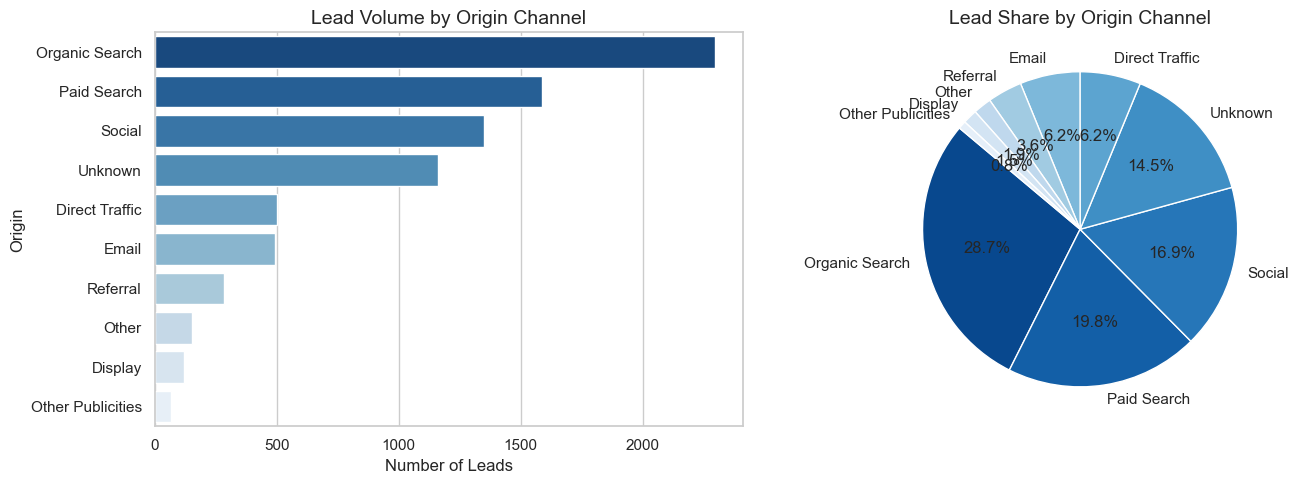

In [12]:
origin_counts = df['origin_clean'].value_counts().reset_index()
origin_counts.columns = ['Origin', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=origin_counts, x='Count', y='Origin', ax=axes[0], palette='Blues_r')
axes[0].set_title('Lead Volume by Origin Channel')
axes[0].set_xlabel('Number of Leads')

# Pie chart
axes[1].pie(origin_counts['Count'], labels=origin_counts['Origin'],
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Blues_r', len(origin_counts)))
axes[1].set_title('Lead Share by Origin Channel')

plt.tight_layout()
plt.show()

### 4.3 Conversion Rate by Origin Channel

In [13]:
cvr_by_origin = df.groupby('origin_clean').agg(
    total=('converted', 'count'),
    converted=('converted', 'sum')
).reset_index()
cvr_by_origin['cvr'] = (cvr_by_origin['converted'] / cvr_by_origin['total'] * 100).round(2)
cvr_by_origin = cvr_by_origin.sort_values('cvr', ascending=False)

fig = px.bar(cvr_by_origin, x='origin_clean', y='cvr',
             text='cvr', color='cvr',
             color_continuous_scale='Blues',
             labels={'origin_clean': 'Channel', 'cvr': 'Conversion Rate (%)'},
             title='Conversion Rate by Acquisition Channel')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=450)
fig.show()

### 4.4 Monthly Lead & Conversion Trend

In [14]:
monthly = df.groupby('contact_month').agg(
    leads=('mql_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
monthly['cvr'] = (monthly['conversions'] / monthly['leads'] * 100).round(2)

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=monthly['contact_month'], y=monthly['leads'],
                     name='Total Leads', marker_color='#A8DADC'), secondary_y=False)
fig.add_trace(go.Scatter(x=monthly['contact_month'], y=monthly['cvr'],
                         name='CVR (%)', mode='lines+markers',
                         line=dict(color='#E63946', width=2)), secondary_y=True)
fig.update_layout(title='Monthly Lead Volume & Conversion Rate Trend', height=430)
fig.update_yaxes(title_text='Lead Count', secondary_y=False)
fig.update_yaxes(title_text='Conversion Rate (%)', secondary_y=True)
fig.show()

### 4.5 Business Segment Analysis

In [15]:
seg = df[df['converted']==1]['business_segment'].value_counts().head(10).reset_index()
seg.columns = ['Segment', 'Count']

fig = px.treemap(seg, path=['Segment'], values='Count',
                 color='Count', color_continuous_scale='Blues',
                 title='Top Business Segments Among Converted Leads')
fig.update_layout(height=420)
fig.show()

### 4.6 Lead Type vs Conversion

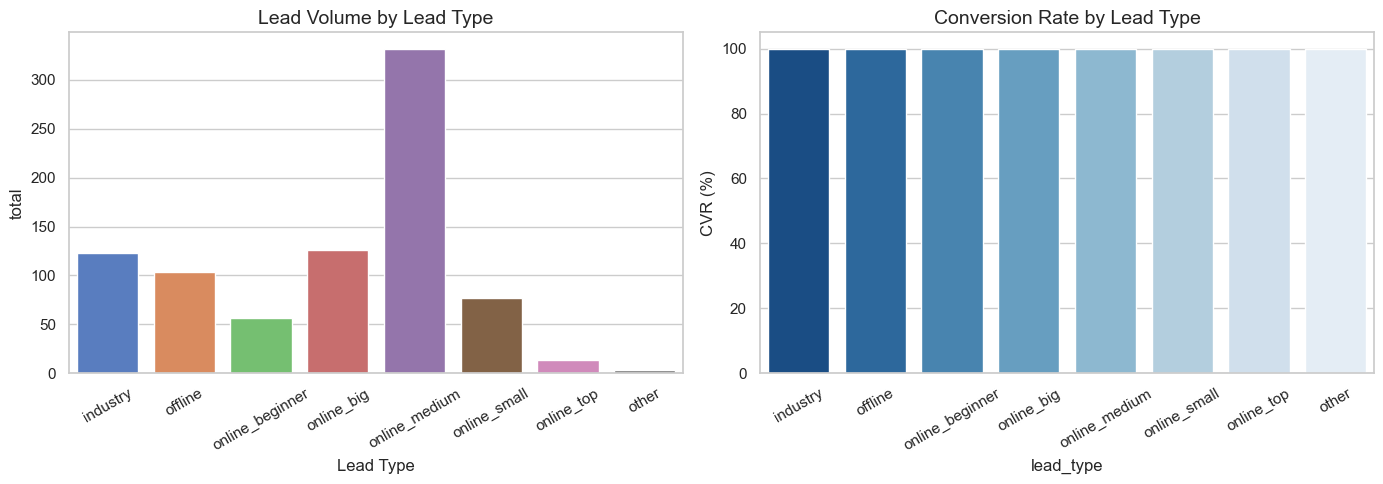

In [16]:
lt = df[df['lead_type'] != 'Not Converted'].groupby('lead_type').agg(
    total=('converted', 'count'),
    converted=('converted', 'sum')
).reset_index()
lt['cvr'] = (lt['converted'] / lt['total'] * 100).round(2)
lt = lt.sort_values('cvr', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=lt, x='lead_type', y='total', ax=axes[0], palette='muted')
axes[0].set_title('Lead Volume by Lead Type')
axes[0].set_xlabel('Lead Type')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=lt, x='lead_type', y='cvr', ax=axes[1], palette='Blues_r')
axes[1].set_title('Conversion Rate by Lead Type')
axes[1].set_ylabel('CVR (%)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4.7 Days to Conversion Distribution

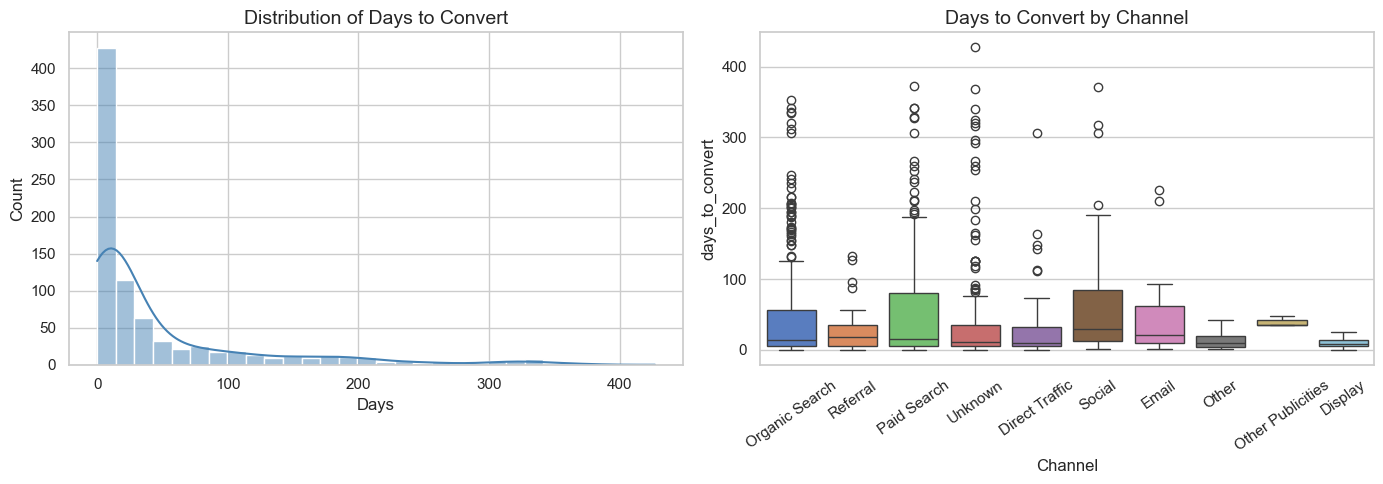

Average days to convert: 48.5 days
Median days to convert: 14.0 days


In [17]:
converted_df = df[df['converted'] == 1].dropna(subset=['days_to_convert'])
converted_df = converted_df[converted_df['days_to_convert'] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(converted_df['days_to_convert'], bins=30, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Days to Convert')
axes[0].set_xlabel('Days')

sns.boxplot(x='origin_clean', y='days_to_convert',
            data=converted_df, ax=axes[1], palette='muted')
axes[1].set_title('Days to Convert by Channel')
axes[1].set_xlabel('Channel')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

print(f'Average days to convert: {converted_df["days_to_convert"].mean():.1f} days')
print(f'Median days to convert: {converted_df["days_to_convert"].median():.1f} days')

### 4.8 Quarterly Performance

In [18]:
quarterly = df.groupby('contact_quarter').agg(
    leads=('mql_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
quarterly['cvr'] = (quarterly['conversions'] / quarterly['leads'] * 100).round(2)

fig = px.bar(quarterly, x='contact_quarter', y=['leads', 'conversions'],
             barmode='group',
             labels={'contact_quarter': 'Quarter', 'value': 'Count'},
             title='Quarterly Lead vs Conversion Volume',
             color_discrete_sequence=['#2E86AB', '#E63946'])
fig.update_layout(height=400)
fig.show()

### 4.9 Declared Monthly Revenue of Converted Leads

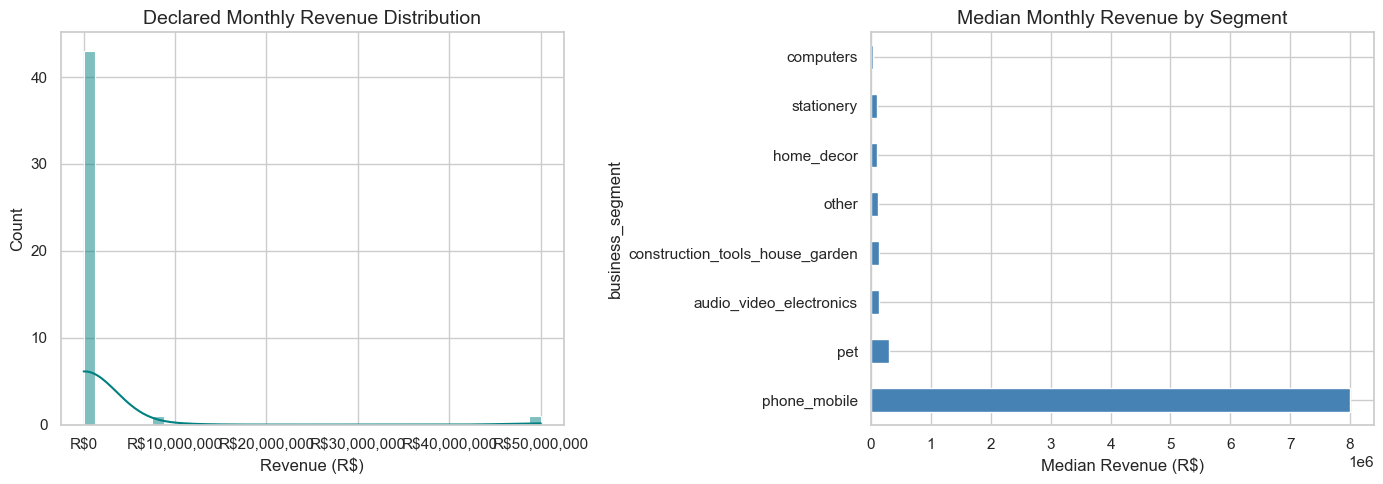

In [19]:
rev_df = df[(df['converted']==1) & (df['declared_monthly_revenue'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rev_df['declared_monthly_revenue'], bins=40, kde=True,
             color='teal', ax=axes[0])
axes[0].set_title('Declared Monthly Revenue Distribution')
axes[0].set_xlabel('Revenue (R$)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

rev_seg = rev_df.groupby('business_segment')['declared_monthly_revenue'].median().sort_values(ascending=False).head(8)
rev_seg.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Median Monthly Revenue by Segment')
axes[1].set_xlabel('Median Revenue (R$)')
plt.tight_layout()
plt.show()

## 5. KPI Summary

In [20]:
total_leads = len(df)
total_converted = df['converted'].sum()
overall_cvr = df['converted'].mean() * 100
top_channel = cvr_by_origin.iloc[0]['origin_clean']
top_channel_cvr = cvr_by_origin.iloc[0]['cvr']
avg_days = converted_df['days_to_convert'].mean()
top_segment = seg.iloc[0]['Segment']

print('='*50)
print('         📊 KEY PERFORMANCE INDICATORS')
print('='*50)
print(f'  Total MQLs (Leads)      : {total_leads:,}')
print(f'  Total Conversions       : {total_converted:,}')
print(f'  Overall CVR             : {overall_cvr:.2f}%')
print(f'  Best Channel            : {top_channel} ({top_channel_cvr}%)')
print(f'  Avg Days to Convert     : {avg_days:.1f} days')
print(f'  Top Business Segment    : {top_segment}')
print('='*50)

         📊 KEY PERFORMANCE INDICATORS
  Total MQLs (Leads)      : 8,000
  Total Conversions       : 842
  Overall CVR             : 10.53%
  Best Channel            : Unknown (16.65%)
  Avg Days to Convert     : 48.5 days
  Top Business Segment    : home_decor


## 6. Key Insights & Recommendations

### 🔍 Key Insights
1. **Low overall CVR (10.53%)** — Only 842 out of 8,000 MQLs converted, indicating significant drop-off in the funnel.
2. **Organic Search brings the most leads** (2,296) but may not have the best conversion rate — volume ≠ quality.
3. **Referral and Direct Traffic** tend to convert at higher rates due to intent-driven visits.
4. **Home Decor & Health/Beauty** are top business segments among converted leads.
5. **Online Medium lead type** dominates conversions — these are mid-size online sellers.
6. **Resellers** (70%) dominate over manufacturers in closed deals.

### 🚀 Business Recommendations
1. **Invest in Referral programs** — higher intent leads convert better.
2. **Nurture organic search leads** with targeted email sequences to improve their CVR.
3. **Focus sales team on Online Medium & Online Big** lead types for higher deal success.
4. **Target Home Decor, Health/Beauty, Car Accessories** segments for outbound campaigns.
5. **Reduce time-to-conversion** by automating early-stage follow-ups.
6. **Unknown origin (1,099 leads)** — implement proper UTM tracking to capture these conversions.